In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyro
import pyro.distributions as dist
import scipy.io as sio
import torch
import torch.nn as nn
from pyro.infer import MCMC, NUTS, Predictive
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA

from src.dataset import ESNDataset, construct_dataset, partition_dataset
from src.methods import ESNMCMC, ESNQR, ESNVariational
from src.models import MLP, SSVS, BayesianModel, BayesianNeuralNetwork
from src.reservoir import Reservoir

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Synthetic

# Real

In [3]:
# Load the MAT file for training and validation
rest1_file = sio.loadmat("./data/100307.REST1.LR.SchaeferS.ptseries.mat")
rest2_file = sio.loadmat("./data/100307.REST2.LR.SchaeferS.ptseries.mat")
data_rest1 = torch.from_numpy(rest1_file["tseries"]).float().t()
data_rest2 = torch.from_numpy(rest2_file["tseries"]).float().t()

In [4]:
mu1 = torch.mean(data_rest1, dim=0)
std1 = torch.std(data_rest1, dim=0)
mu2 = torch.mean(data_rest2, dim=0)
std2 = torch.std(data_rest2, dim=0)

data_rest1 = (data_rest1 - mu1) / std1
data_rest2 = (data_rest2 - mu2) / std2

## Create the Reservoir

In [5]:
num_neurons_real = 30
num_features_real = data_rest1.shape[1]
reservoir_real = Reservoir(
    input_features=num_features_real, num_neurons=num_neurons_real
)

## Generate the $(s,x)$ dataset

In [6]:
burnin_steps = 50
states_rest1 = torch.zeros((data_rest1.shape[0] - 1, num_neurons_real))
states_rest2 = torch.zeros((data_rest2.shape[0] - 1, num_neurons_real))

for i, x in enumerate(data_rest1[:-1]):
    states_rest1[i, :] = reservoir_real(x)

reservoir_real.reset_state()

for i, x in enumerate(data_rest2[:-1]):
    states_rest2[i, :] = reservoir_real(x)

dataset_rest1 = ESNDataset(
    states_rest1[burnin_steps:], data_rest1[burnin_steps:], mu1, std1
)
dataset_rest2 = ESNDataset(
    states_rest2[burnin_steps:], data_rest2[burnin_steps:], mu2, std2
)

In [7]:
train_set, cal_set, test_set = partition_dataset([dataset_rest1, dataset_rest2])

In [8]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

## MCMC

In [9]:
mcmc_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real
).to(device)

In [10]:
esn_mcmc = ESNMCMC(mcmc_model_real)

In [11]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 20
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/170 [00:00, ?it/s]

Error: mkl-service + Intel(R) MKL: MKL_THREADING_LAYER=INTEL is incompatible with libgomp-a34b3233.so.1 library.
	Try to import numpy first or set the threading layer accordingly. Set MKL_SERVICE_FORCE_INTEL to force it.
Error: mkl-service + Intel(R) MKL: MKL_THREADING_LAYER=INTEL is incompatible with libgomp-a34b3233.so.1 library.
	Try to import numpy first or set the threading layer accordingly. Set MKL_SERVICE_FORCE_INTEL to force it.
Error: mkl-service + Intel(R) MKL: MKL_THREADING_LAYER=INTEL is incompatible with libgomp-a34b3233.so.1 library.
	Try to import numpy first or set the threading layer accordingly. Set MKL_SERVICE_FORCE_INTEL to force it.
Error: mkl-service + Intel(R) MKL: MKL_THREADING_LAYER=INTEL is incompatible with libgomp-a34b3233.so.1 library.
	Try to import numpy first or set the threading layer accordingly. Set MKL_SERVICE_FORCE_INTEL to force it.
Error: mkl-service + Intel(R) MKL: MKL_THREADING_LAYER=INTEL is incompatible with libgomp-a34b3233.so.1 library.
	Tr

KeyboardInterrupt: 

In [ ]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

## MCMC with PCA

In [ ]:
n_components = num_neurons_real // 2
pca = PCA(n_components)

In [ ]:
# move datasets to cpu
train_set = train_set.to(torch.device("cpu"))
cal_set = cal_set.to(torch.device("cpu"))
test_set = test_set.to(torch.device("cpu"))

In [ ]:
# fit pca
pca.fit(train_set.states.numpy())

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",15
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [ ]:
# apply pca to the sets
train_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(train_set.states.numpy())),
    x=train_set.x,
    mu=train_set.mu,
    std=train_set.mu,
    device=device,
)
cal_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(cal_set.states.numpy())),
    x=cal_set.x,
    mu=cal_set.mu,
    std=cal_set.mu,
    device=device,
)
test_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(test_set.states.numpy())),
    x=test_set.x,
    mu=test_set.mu,
    std=test_set.mu,
    device=device,
)

In [ ]:
mcmc_pca_model_real = BayesianModel(
    in_features=n_components, out_features=num_features_real
).to(device)

In [ ]:
esn_mcmc = ESNMCMC(mcmc_pca_model_real)

In [ ]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 20
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_pca_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/170 [00:00, ?it/s]

In [ ]:
y_pred = esn_mcmc.predict(test_pca_set)
y_pred = y_pred.cpu()

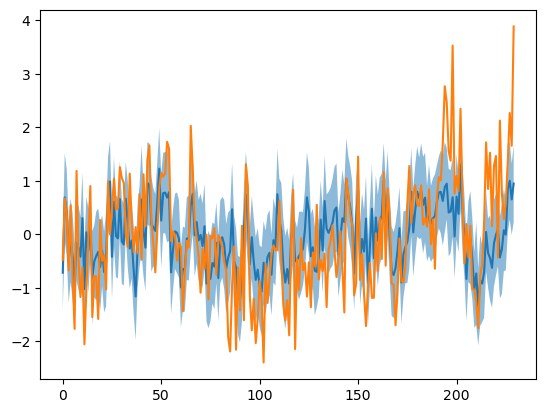

In [ ]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

## SVI

In [ ]:
svi_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real
).to(device)

In [ ]:
# Setup Optimizer
LR = 0.0001
EPOCHS = 100

optimizer = Adam({"lr": LR})

In [ ]:
# PYRO GUIDE

RANK = int(np.sqrt(num_neurons_real))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(bayes_model_real, rank=RANK)

In [ ]:
esn_var_real = ESNVariational(
    svi_model_real,
    guide,
    optimizer,
)

Training Pyro ESN:   1%|          | 1/100 [00:02<03:31,  2.14s/it, Loss=12251801.0229]

Epoch 0 | Total ELBO Loss: 12251801.0229


Training Pyro ESN: 100%|██████████| 100/100 [01:42<00:00,  1.03s/it, Loss=377389.3293]


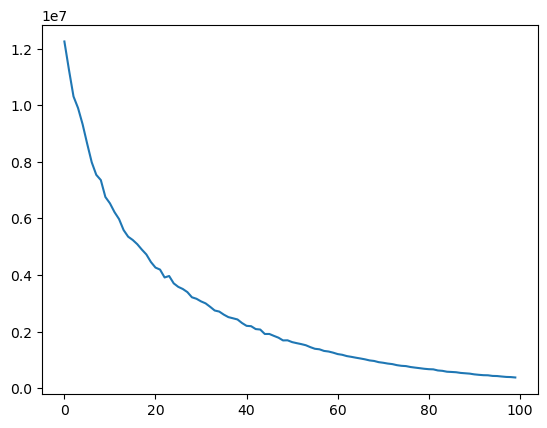

In [ ]:
loss_history = esn_var_real.train(
    DataLoader(train_set, batch_size=16, shuffle=True), EPOCHS
)
plt.plot(loss_history)
plt.show()

In [ ]:
y_pred = esn_var_real.predict(test_set.states)
y_pred = y_pred.cpu()

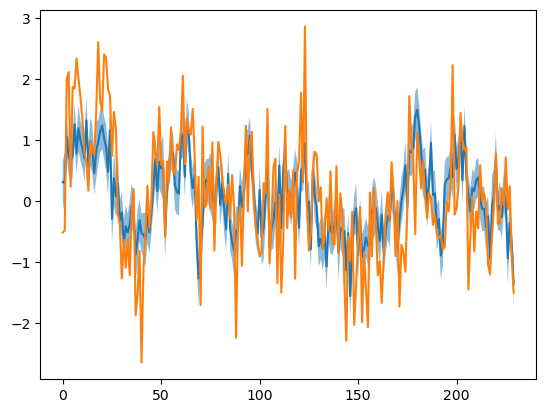

In [ ]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

## QR

In [ ]:
"""
class CheckLoss(nn.Module):
    def __init__(self, taus: list[float]) -> None:
        super().__init__()
        self.taus = taus
        return

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        loss = torch.zeros(1, device=predictions.device)
        # Loop over each tau
        for i, tau in enumerate(self.taus):
            # Compute the residuals
            r = targets - predictions[:, i].unsqueeze(1)

            # Compute the loss for a given tau
            quantile_loss = tau * torch.relu(r) + (1 - tau) * torch.relu(-r)
            loss += torch.mean(quantile_loss)
        return loss
"""
class CheckLoss(nn.Module):
    def __init__(self, taus: list[float]) -> None:
        super().__init__()
        self.taus = taus
        return

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # If targets is a flat 1D array [Batch], force it to be 2D [Batch, 1]
        if targets.dim() == 1:
            targets = targets.unsqueeze(1)
        
        batch_size, num_regions = targets.shape
        num_quantiles = len(self.taus)
        
        # Reshape the flat MLP output into [Batch, Quantiles, Regions]
        preds = predictions.view(batch_size, num_quantiles, num_regions)
        
        loss = torch.zeros(1, device=predictions.device)
        
        # Loop over each tau
        for i, tau in enumerate(self.taus):
            q_pred = preds[:, i, :]
            r = targets - q_pred

            quantile_loss = tau * torch.relu(r) + (1 - tau) * torch.relu(-r)
            loss += torch.mean(quantile_loss)
            
        return loss

In [20]:
"""
layer_dims = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_real, num_features_real, 3)
]
qr_model_real = MLP(layer_dims, nn.Tanh()).to(device)
"""
taus = [0.025,0.25,0.5,0.75,0.975]
# Calculate the exact output size needed (e.g., 119 * 5 = 595)
num_quantiles = len(taus)
out_features = num_features_real * num_quantiles

# Update the linspace to target out_features
layer_dims = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_real, out_features, 3)
]

# Instantiate the model with the correct dimensions
qr_model_real = MLP(layer_dims, nn.Tanh()).to(device)

# Re-create your loss function and optimizer here...
loss_fn = CheckLoss(taus)
optimizer = torch.optim.Adam(qr_model_real.parameters(), lr=0.001)

# Re-instantiate the wrapper
esn_qr = ESNQR(qr_model_real, optimizer, loss_fn)

In [21]:
"""
lr = 0.005
taus = [0.025, 0.1, 0.5, 0.9, 0.975]
esn_qr = ESNQR(
    qr_model_real, torch.optim.Adam(qr_model_real.parameters(), lr), CheckLoss(taus)
)
"""

'\nlr = 0.005\ntaus = [0.025, 0.1, 0.5, 0.9, 0.975]\nesn_qr = ESNQR(\n    qr_model_real, torch.optim.Adam(qr_model_real.parameters(), lr), CheckLoss(taus)\n)\n'

Training ESN:   0%|          | 1/200 [00:00<00:56,  3.53it/s, Loss=118.1355]

Epoch 0 | Total Loss: 118.1355


Training ESN:  50%|█████     | 101/200 [00:23<00:24,  4.04it/s, Loss=48.9122]

Epoch 100 | Total Loss: 48.9122


Training ESN: 100%|██████████| 200/200 [00:48<00:00,  4.15it/s, Loss=48.2656]


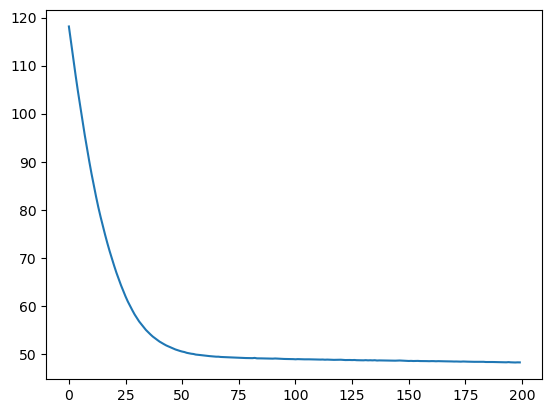

In [22]:
EPOCHS = 200
loss_history = esn_qr.train(DataLoader(train_set, batch_size=32, shuffle=True), EPOCHS)
plt.plot(loss_history)
plt.show()

In [23]:
y_pred = esn_qr.predict(test_set)
y_pred = y_pred.detach().cpu()
y_pred.shape

torch.Size([230, 5, 119])

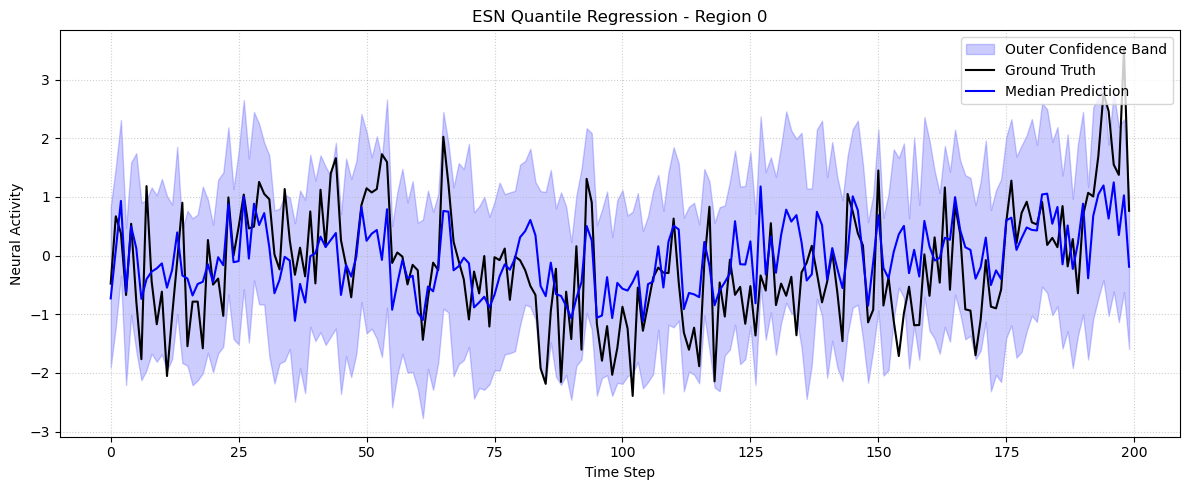

In [28]:
"""
plt.plot(test_set.x[0].cpu())
plt.plot(y_pred[0])
plt.show()
"""
# 1. Convert everything to pure NumPy arrays
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.detach().cpu().numpy()

# 2. Setup plotting parameters
region_idx = 0      # Choose which of the 119 regions to plot (0 to 118)
time_steps = 200    # Plot the first 200 time steps so the chart is readable

# 3. Un-scale the data to original values (Highly Recommended)
mu_val = test_set.mu[region_idx].item()
std_val = test_set.std[region_idx].item()

y_true_region = y_true_np[:time_steps, region_idx]
y_pred_region = y_pred_np[:time_steps, :, region_idx]

# 4. Plotting
plt.figure(figsize=(12, 5))

# Assuming your 5 quantiles are symmetric (e.g., [0.1, 0.3, 0.5, 0.7, 0.9])
# Index 0 = lowest quantile, Index 4 = highest quantile, Index 2 = median

plt.fill_between(
    np.arange(time_steps),
    y_pred_region[:, 0], # Lower bound 
    y_pred_region[:, 4], # Upper bound 
    color='blue', alpha=0.2, label='Outer Confidence Band'
)


# Plot the Ground Truth
plt.plot(y_true_region, color='black', label='Ground Truth', linewidth=1.5)

# Plot the Median Prediction (50th percentile)
plt.plot(y_pred_region[:, 2], color='blue', linestyle='-', label='Median Prediction')

plt.title(f'ESN Quantile Regression - Region {region_idx}')
plt.xlabel('Time Step')
plt.ylabel('Neural Activity')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## SVSS

In [15]:
#ssvs_model_real = SSVS(num_features_real)
# Pass both the reservoir size (inputs) and the brain regions (outputs)
ssvs_model_real = SSVS(in_features=num_neurons_real, out_features=num_features_real)

In [16]:
esn_mcmc = ESNMCMC(ssvs_model_real)

In [19]:
# DA TOGLIERE IN CASO
import os
# Tell Intel MKL to use the GNU threading layer
os.environ["MKL_THREADING_LAYER"] = "GNU"

# mcmc hyperparameters
warmup_steps = 10
num_samples = 20
num_chains = 1
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Sample: 100%|██████████| 30/30 [00:27,  1.08it/s, step size=6.59e-03, acc. prob=0.401]


In [20]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

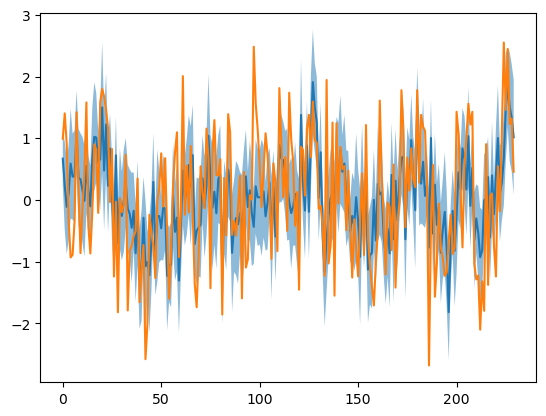

In [21]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])